In [ ]:
# ============================================
# CELL 1: Setup for EDA
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

base_path = '/content/drive/MyDrive/capstone_project'
merged = pd.read_csv(f'{base_path}/processed_data/final_dataset.csv')
merged['date'] = pd.to_datetime(merged['date'])

print(f"✅ Loaded {len(merged)} rows")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Precincts: {merged['precinct'].nunique()}")

Mounted at /content/drive
✅ Loaded 92904 rows
Date range: 2015-01-01 to 2020-03-10
Precincts: 49


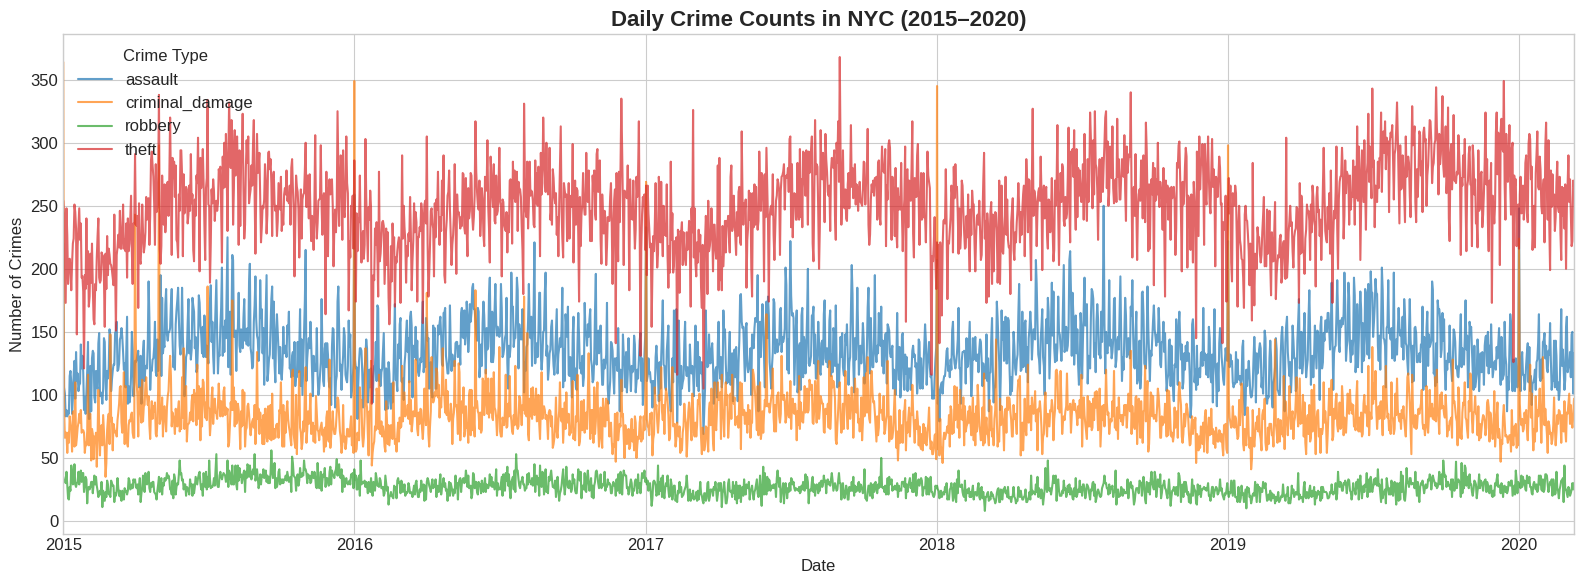

✅ Saved: crime_over_time.png


In [ ]:
# ============================================
# CELL 2: Total crime counts over time
# ============================================
daily_total = merged.groupby('date')[['assault', 'criminal_damage', 'robbery', 'theft']].sum()

fig, ax = plt.subplots(figsize=(16, 6))
daily_total.plot(ax=ax, alpha=0.7)
ax.set_title('Daily Crime Counts in NYC (2015–2020)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Crimes')
ax.legend(title='Crime Type')
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/crime_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: crime_over_time.png")

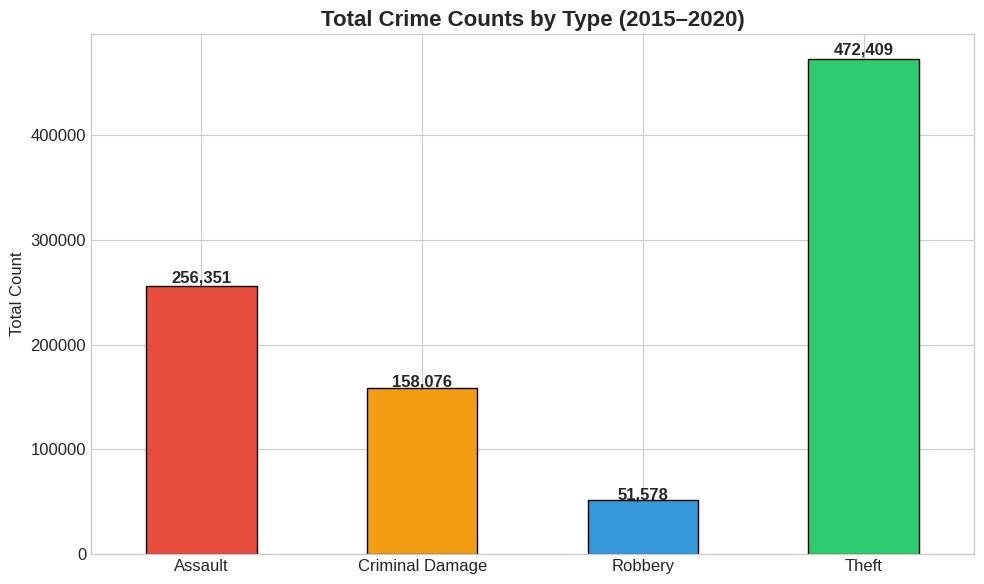

✅ Saved: crime_by_type.png


In [ ]:
# ============================================
# CELL 3: Total crimes by type - bar chart
# ============================================
totals = merged[['assault', 'criminal_damage', 'robbery', 'theft']].sum()
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
totals.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Total Crime Counts by Type (2015–2020)', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Count')
ax.set_xticklabels(['Assault', 'Criminal Damage', 'Robbery', 'Theft'], rotation=0)

for i, v in enumerate(totals):
    ax.text(i, v + v*0.01, f'{int(v):,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{base_path}/outputs/crime_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: crime_by_type.png")

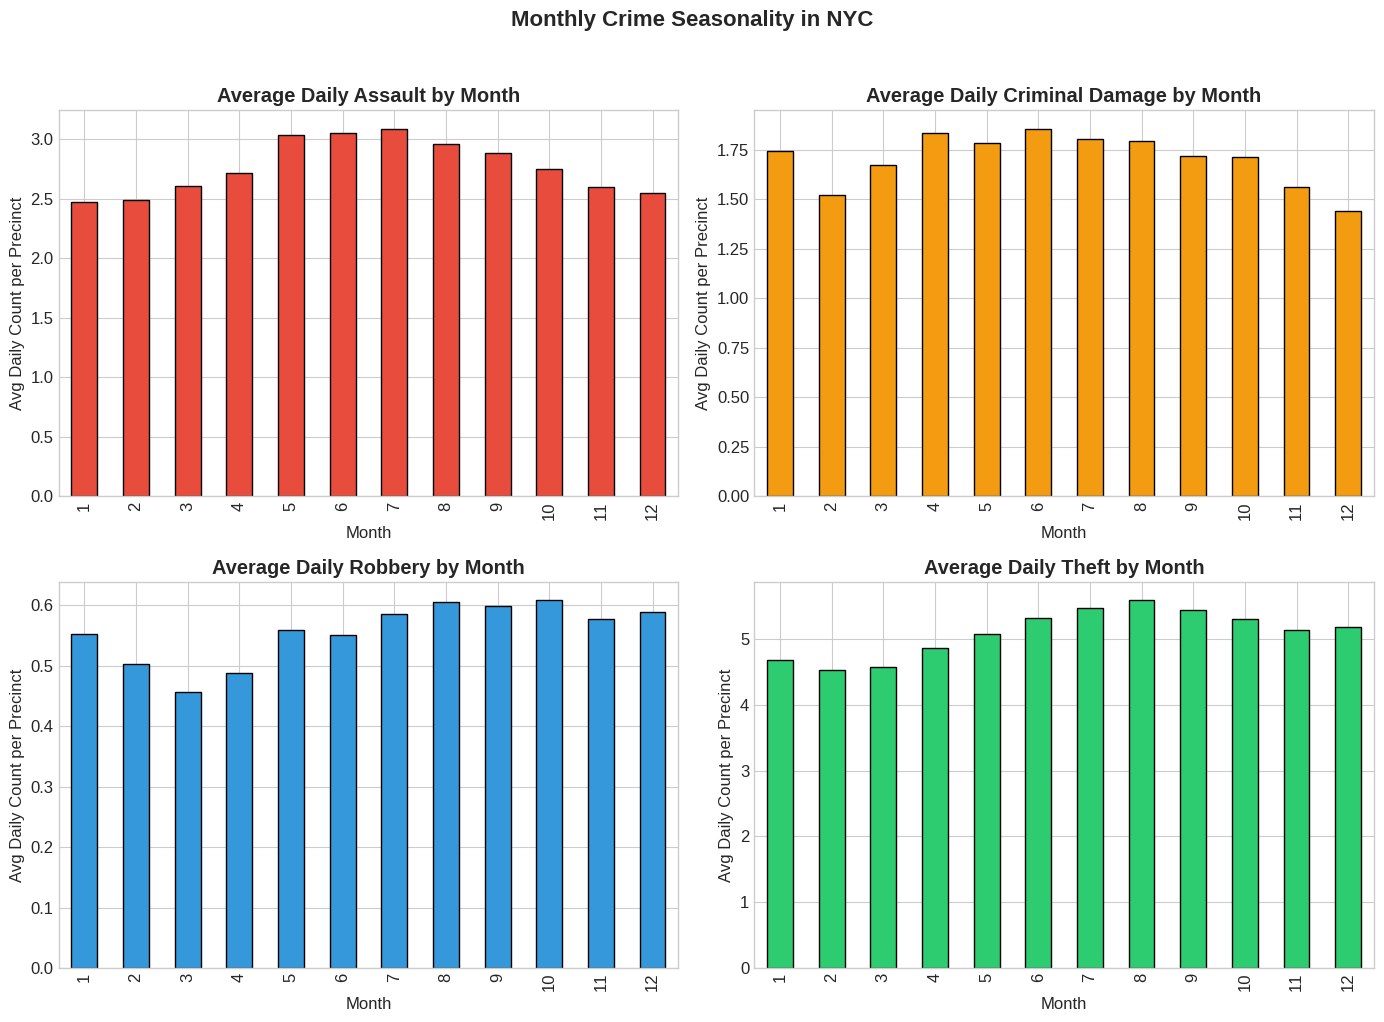

✅ Saved: monthly_seasonality.png


In [ ]:
# ============================================
# CELL 4: Monthly crime patterns (seasonality)
# ============================================
merged['month_num'] = merged['date'].dt.month
monthly = merged.groupby('month_num')[['assault', 'criminal_damage', 'robbery', 'theft']].mean()
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
crime_types = ['assault', 'criminal_damage', 'robbery', 'theft']
titles = ['Assault', 'Criminal Damage', 'Robbery', 'Theft']

for idx, (crime, title) in enumerate(zip(crime_types, titles)):
    ax = axes[idx // 2, idx % 2]
    monthly[crime].plot(kind='bar', ax=ax, color=colors[idx], edgecolor='black')
    ax.set_title(f'Average Daily {title} by Month', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Daily Count per Precinct')

plt.suptitle('Monthly Crime Seasonality in NYC', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: monthly_seasonality.png")

/tmp/ipykernel_577/421897723.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dow_avg = merged.groupby('dow')[['assault', 'criminal_damage', 'robbery', 'theft']].mean()


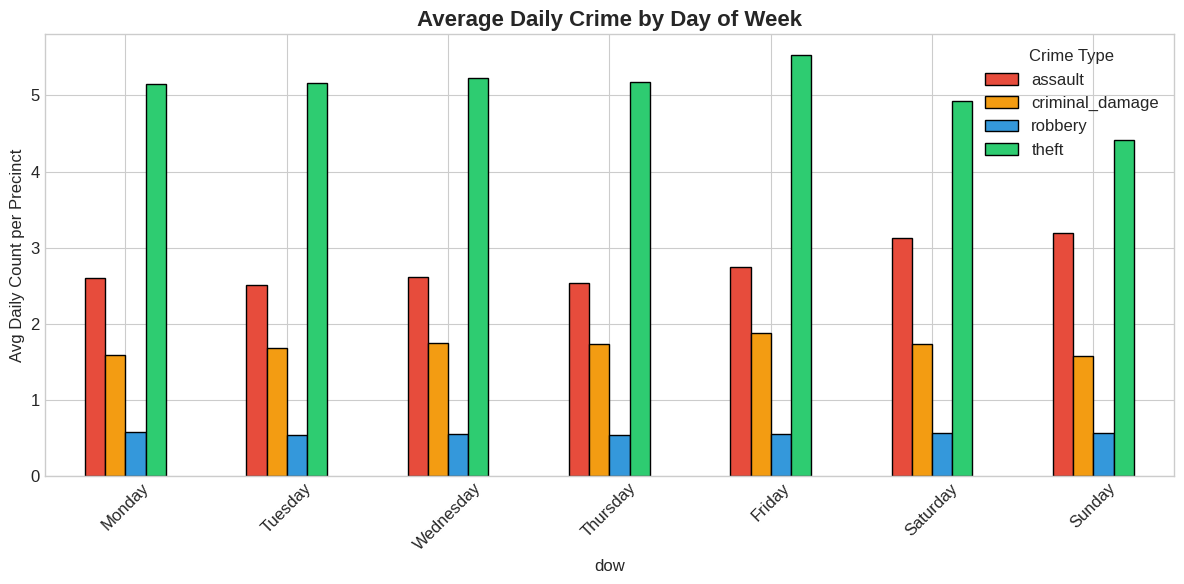

✅ Saved: day_of_week.png


In [ ]:
# ============================================
# CELL 5: Day-of-week patterns
# ============================================
merged['dow'] = merged['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
merged['dow'] = pd.Categorical(merged['dow'], categories=dow_order, ordered=True)

dow_avg = merged.groupby('dow')[['assault', 'criminal_damage', 'robbery', 'theft']].mean()

fig, ax = plt.subplots(figsize=(12, 6))
dow_avg.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Average Daily Crime by Day of Week', fontsize=16, fontweight='bold')
ax.set_ylabel('Avg Daily Count per Precinct')
ax.set_xticklabels(dow_order, rotation=45)
ax.legend(title='Crime Type')
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: day_of_week.png")

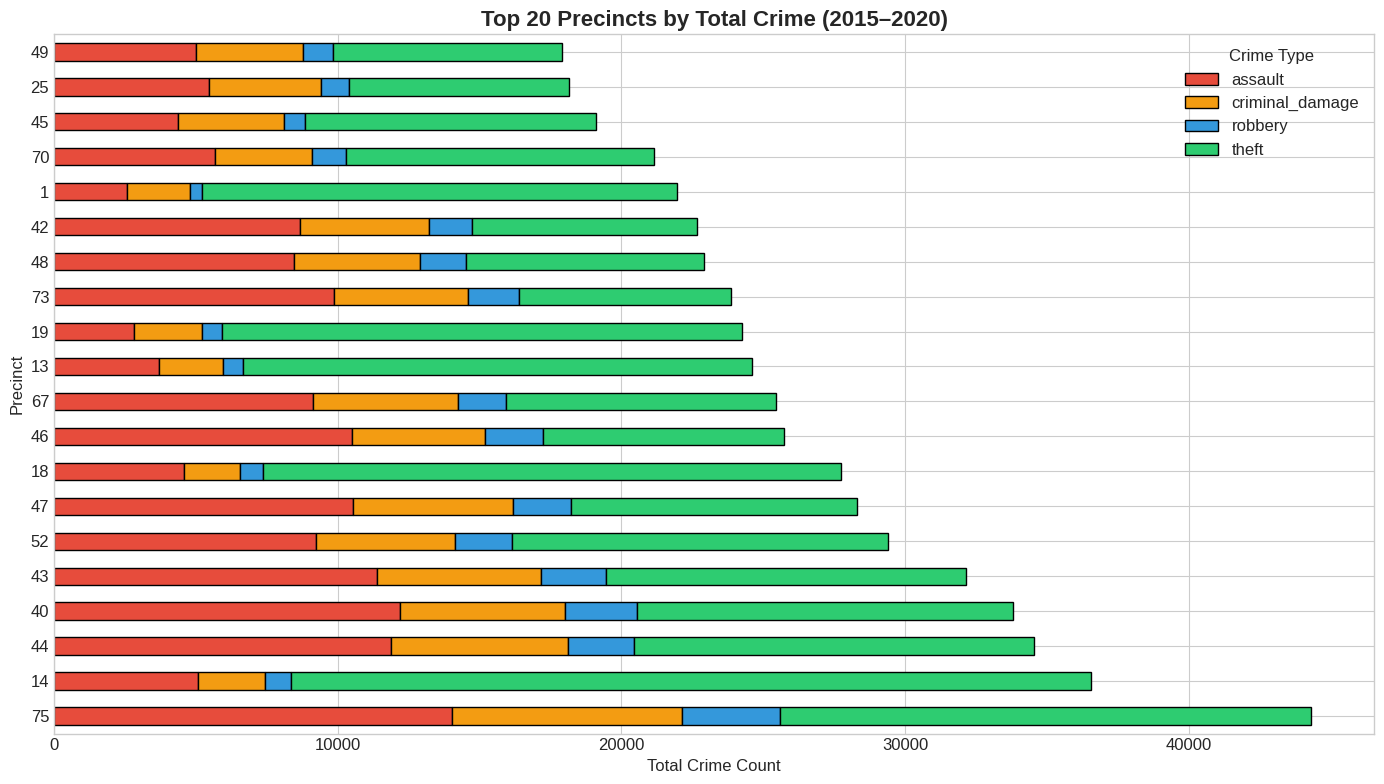

✅ Saved: top_precincts.png


In [ ]:
# ============================================
# CELL 6: Top 20 precincts by total crime
# ============================================
precinct_totals = merged.groupby('precinct')[['assault', 'criminal_damage', 'robbery', 'theft']].sum()
precinct_totals['total'] = precinct_totals.sum(axis=1)
top20 = precinct_totals.nlargest(20, 'total')

fig, ax = plt.subplots(figsize=(14, 8))
top20[['assault', 'criminal_damage', 'robbery', 'theft']].plot(
    kind='barh', ax=ax, stacked=True, color=colors, edgecolor='black'
)
ax.set_title('Top 20 Precincts by Total Crime (2015–2020)', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Crime Count')
ax.set_ylabel('Precinct')
ax.legend(title='Crime Type')
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/top_precincts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: top_precincts.png")

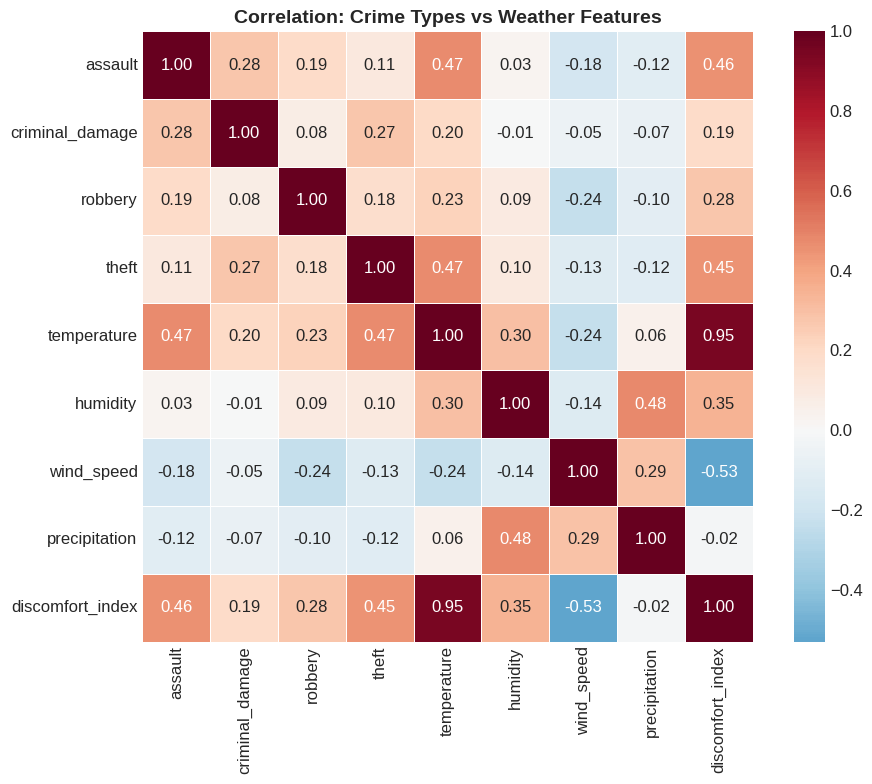

✅ Saved: correlation_heatmap.png


In [ ]:
# ============================================
# CELL 7: Correlation between crime and weather
# ============================================
daily_agg = merged.groupby('date').agg({
    'assault': 'sum', 'criminal_damage': 'sum', 'robbery': 'sum', 'theft': 'sum',
    'temperature': 'first', 'humidity': 'first', 'wind_speed': 'first',
    'precipitation': 'first', 'discomfort_index': 'first'
}).reset_index()

corr_cols = ['assault', 'criminal_damage', 'robbery', 'theft',
             'temperature', 'humidity', 'wind_speed', 'precipitation', 'discomfort_index']
corr_matrix = daily_agg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation: Crime Types vs Weather Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

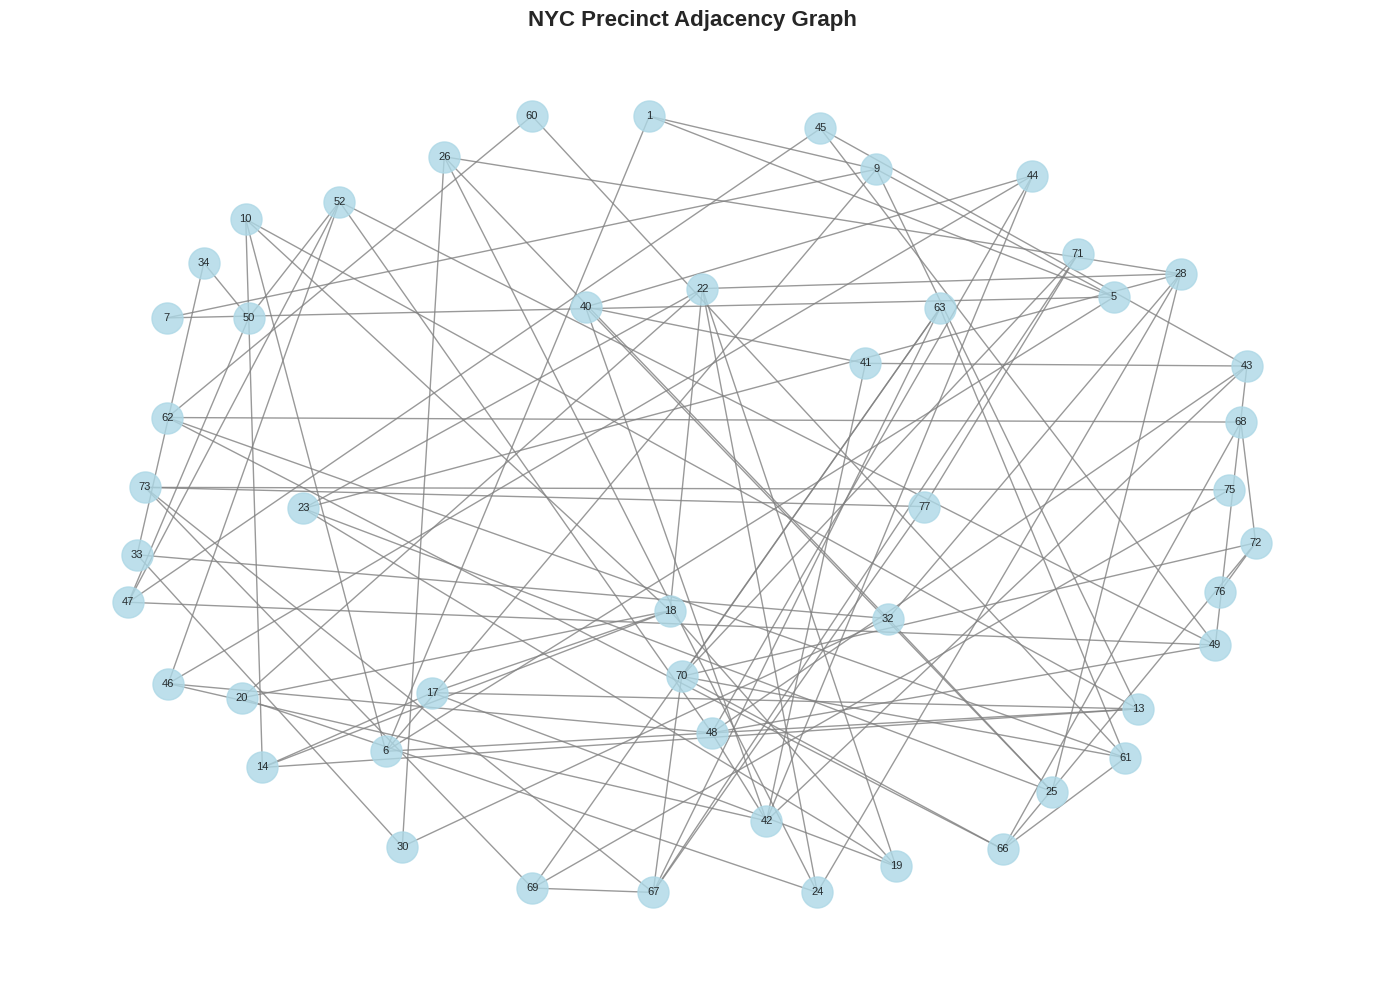

Nodes: 49, Edges: 99
✅ Saved: adjacency_graph.png


In [ ]:
# ============================================
# CELL 8: Visualize precinct adjacency graph
# ============================================
!pip install networkx -q
import networkx as nx

adj_matrix = np.load(f'{base_path}/processed_data/adjacency_matrix.npy')
precinct_ids = np.load(f'{base_path}/processed_data/precinct_ids.npy')

G = nx.from_numpy_array(adj_matrix)
mapping = {i: int(precinct_ids[i]) for i in range(len(precinct_ids))}
G = nx.relabel_nodes(G, mapping)
G.remove_edges_from(nx.selfloop_edges(G))

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=2)
nx.draw(G, pos, ax=ax, with_labels=True, node_color='lightblue',
        node_size=500, font_size=8, edge_color='gray', alpha=0.8)
ax.set_title('NYC Precinct Adjacency Graph', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base_path}/outputs/adjacency_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print("✅ Saved: adjacency_graph.png")